# Setup

## Parameters
Tunable parameters and paths for the tax-risk pipeline
All knobs live here so reviewers can see and change assumptions in one place.
See docs/adr/ for the decisions these encode.

In [4]:
suppressPackageStartupMessages({
library(dplyr)
library(ggplot2)
library(scales)
library(knitr)
})

In [2]:
CONFIG <- list(
  # --- data ---
  data_path          = "test_dataset.csv",      # real 1500-row file (ADR-006 open item)
  data_path_fallback = "test_dataset_smp.csv",  # 10-row sample for smoke tests
  out_dir            = "output",

  # --- benchmarking (ADR-004) ---
  group_col       = "okved_section",  # sector used for peer comparison
  min_cell_size   = 8,                # sectors smaller than this fall back up the hierarchy
  robust_z_flag   = 3.5,              # |modified z| above which a continuous metric is flagged
  identity_tol    = 0.005,            # relative tolerance for accounting-identity checks (0.5%)

  # --- typology-specific ---
  shell_headcount_max = 5,            # "shell/transit" headcount ceiling
  young_age_max       = 2,            # "young firm" = age (year - ogrn_year) <= this
  yoy_flag_z          = 3.5,          # robust z for YoY revenue change

  # --- scoring (ADR-005) ---
  tier_weights = c("1" = 2, "2" = 1), # Tier-1 flags weigh double
  severity_cap = 8,                   # cap |robust z| contribution so one metric can't dominate

  # --- bucketing (ADR-005) ---
  likelihood_hi_q = 0.80,             # composite-score quantile for "high likelihood"
  materiality_hi_q = 0.80,            # materiality quantile for "high materiality"

  seed = 42
)

dir.create(CONFIG$out_dir, showWarnings = FALSE, recursive = TRUE)
set.seed(CONFIG$seed)

Typology detectors (ADR-003)
Continuous metrics: robust sector-relative modified z-scores with
small-cell fallback (ADR-004). Impossibilities: absolute boolean rules.

In [5]:
# Modified z-score = 0.6745 * (x - median) / MAD. Robust to the outliers we hunt.
.modified_z <- function(x, center, spread) {
  z <- 0.6745 * (x - center) / spread
  z[!is.finite(z)] <- NA_real_
  z
}

# Robust z within `group`, falling back to global stats when a group cell is
# too small or degenerate (MAD == 0). Returns z and the fallback level used.
robust_z_by_group <- function(x, group, min_n = CONFIG$min_cell_size) {
  glob_center <- stats::median(x, na.rm = TRUE)
  glob_mad    <- stats::mad(x, na.rm = TRUE)
  if (!is.finite(glob_mad) || glob_mad == 0) {
    glob_mad <- stats::IQR(x, na.rm = TRUE) / 1.349
  }
  if (!is.finite(glob_mad) || glob_mad == 0) glob_mad <- NA_real_

  z     <- rep(NA_real_, length(x))
  level <- rep("global", length(x))

  for (g in unique(group)) {
    idx <- which(group == g)
    xv  <- x[idx]
    n   <- sum(is.finite(xv))
    center <- stats::median(xv, na.rm = TRUE)
    spread <- stats::mad(xv, na.rm = TRUE)
    use_group <- n >= min_n && is.finite(spread) && spread > 0
    if (use_group) {
      z[idx]     <- .modified_z(xv, center, spread)
      level[idx] <- "sector"
    } else {
      z[idx]     <- .modified_z(xv, glob_center, glob_mad)
      level[idx] <- "global"
    }
  }
  list(z = z, level = level)
}

# Each detector returns a logical flag + a severity (|z| or fixed) per company-year.
run_typologies <- function(cy, config = CONFIG) {
  g <- cy[[config$group_col]]
  thr <- config$robust_z_flag

  z_etr    <- robust_z_by_group(cy$etr, g)
  z_taxrev <- robust_z_by_group(cy$tax_to_revenue, g)
  z_rph    <- robust_z_by_group(cy$revenue_per_head, g)
  z_opm    <- robust_z_by_group(cy$operating_margin, g)
  z_gm     <- robust_z_by_group(cy$gross_margin, g)
  z_div    <- robust_z_by_group(cy$dividend_payout, g)
  z_pph    <- robust_z_by_group(cy$payroll_per_head, g)
  z_yoy    <- robust_z_by_group(cy$max_abs_revenue_yoy, g)
  z_rev    <- robust_z_by_group(cy$revenue, g)

  false_na <- function(v) { v[is.na(v)] <- FALSE; v }
  # magnitude severity: |z| capped, NA -> 0
  mag <- function(v) { v <- abs(v); v[!is.finite(v)] <- 0; pmin(v, config$severity_cap) }
  # low-tail severity: magnitude of the negative part only
  lowmag <- function(v) { v <- abs(pmin(v, 0)); v[!is.finite(v)] <- 0; pmin(v, config$severity_cap) }

  out <- cy %>% transmute(company_id, company_name, year, !!config$group_col := .data[[config$group_col]])

  # ---- Tier 1 ----
  # 1. Low effective tax rate (low tail); corroborated by low tax-to-revenue
  out$flag_low_etr <- false_na(z_etr$z <= -thr | z_taxrev$z <= -thr)
  out$sev_low_etr  <- ifelse(out$flag_low_etr, pmax(lowmag(z_etr$z), lowmag(z_taxrev$z)), 0)

  # 2. Shell / transit: high revenue-per-head AND tiny headcount
  out$flag_shell <- false_na(z_rph$z >= thr & cy$headcount <= config$shell_headcount_max)
  out$sev_shell  <- ifelse(out$flag_shell, mag(z_rph$z), 0)

  # 3. Dividend stripping: high payout ratio OR dividends exceed net profit (absolute)
  div_gt_net <- false_na(cy$dividends_paid > cy$net_profit & cy$dividends_paid > 0)
  out$flag_dividend <- false_na(z_div$z >= thr) | div_gt_net
  out$sev_dividend  <- ifelse(out$flag_dividend,
                              pmax(mag(z_div$z), ifelse(div_gt_net, config$robust_z_flag, 0)), 0)

  # 4. Margin anomaly vs sector (either tail, operating or gross)
  out$flag_margin <- false_na(abs(z_opm$z) >= thr | abs(z_gm$z) >= thr)
  out$sev_margin  <- ifelse(out$flag_margin, pmax(mag(z_opm$z), mag(z_gm$z)), 0)

  # ---- Tier 2 ----
  # 5. Accounting-identity violations (absolute, relative tolerance)
  out$flag_identity <- false_na(cy$id_gross_resid > config$identity_tol |
                                cy$id_op_resid    > config$identity_tol)
  out$sev_identity  <- ifelse(out$flag_identity, config$robust_z_flag, 0)

  # 6. Sudden YoY revenue jump/collapse
  out$flag_yoy <- false_na(z_yoy$z >= config$yoy_flag_z)
  out$sev_yoy  <- ifelse(out$flag_yoy, mag(z_yoy$z), 0)

  # 7. Young firm with very large revenue
  out$flag_young_big <- false_na(cy$company_age <= config$young_age_max & z_rev$z >= thr)
  out$sev_young_big  <- ifelse(out$flag_young_big, mag(z_rev$z), 0)

  # 8. Wage anomalies (payroll per head either tail)
  out$flag_wage <- false_na(abs(z_pph$z) >= thr)
  out$sev_wage  <- ifelse(out$flag_wage, mag(z_pph$z), 0)

  # keep benchmark levels for auditability
  out$etr_bench_level <- z_etr$level
  out
}

TIER1_FLAGS <- c("flag_low_etr", "flag_shell", "flag_dividend", "flag_margin")
TIER2_FLAGS <- c("flag_identity", "flag_yoy", "flag_young_big", "flag_wage")
FLAG_SEV_MAP <- c(
  flag_low_etr = "sev_low_etr", flag_shell = "sev_shell",
  flag_dividend = "sev_dividend", flag_margin = "sev_margin",
  flag_identity = "sev_identity", flag_yoy = "sev_yoy",
  flag_young_big = "sev_young_big", flag_wage = "sev_wage"
)

# Загрузка данных

In [28]:
EXPECTED_COLS <- c(
  "company_id", "company_name", "inn", "ogrn_year", "region",
  "okved_code", "okved_section", "founder_id", "address_hash", "year",
  "revenue", "cost_of_goods", "gross_profit", "opex", "operating_profit",
  "net_profit", "taxes_paid", "headcount", "payroll_fund", "dividends_paid"
)

NUMERIC_COLS <- c(
  "ogrn_year", "year", "revenue", "cost_of_goods", "gross_profit", "opex",
  "operating_profit", "net_profit", "taxes_paid", "headcount",
  "payroll_fund", "dividends_paid"
)

load_data <- function(config = CONFIG) {
  path <- config$data_path
  if (!file.exists(path)) {
    warning(sprintf("'%s' not found -- falling back to sample '%s' (SMOKE TEST ONLY).",
                    path, config$data_path_fallback))
    path <- config$data_path_fallback
  }
  if (!file.exists(path)) {
    stop(sprintf("No data file found (looked for '%s' and '%s').",
                 config$data_path, config$data_path_fallback))
  }

  dat <- read_csv(path, show_col_types = FALSE, progress = FALSE)

  # schema validation
  missing <- setdiff(EXPECTED_COLS, names(dat))
  if (length(missing) > 0) {
    stop("Dataset is missing expected columns: ", paste(missing, collapse = ", "))
  }
  dat <- dat[, EXPECTED_COLS]

  for (col in NUMERIC_COLS) {
    dat[[col]] <- suppressWarnings(as.numeric(dat[[col]]))
  }

  attr(dat, "source_path") <- path
  attr(dat, "is_sample")   <- identical(basename(path), basename(config$data_path_fallback))
  message(sprintf("Loaded %d rows x %d cols from %s%s",
                  nrow(dat), ncol(dat), path,
                  if (isTRUE(attr(dat, "is_sample"))) "  [SAMPLE]" else ""))
  dat
}

# Генерация признаков

In [7]:
safe_ratio <- function(num, den, den_positive_only = TRUE) {
  out <- num / den
  bad <- if (den_positive_only) den <= 0 | is.na(den) else den == 0 | is.na(den)
  out[bad] <- NA_real_
  out
}

# --- company-year level ratios ---
build_company_year_features <- function(dat, config = CONFIG) {
  dat %>%
    mutate(
      company_age      = year - ogrn_year,
      etr              = safe_ratio(taxes_paid, operating_profit),          # ADR-005 primary, NA if op<=0
      tax_to_revenue   = safe_ratio(taxes_paid, revenue),                   # secondary corroborator
      gross_margin     = safe_ratio(gross_profit, revenue),
      operating_margin = safe_ratio(operating_profit, revenue),
      net_margin       = safe_ratio(net_profit, revenue),
      revenue_per_head = safe_ratio(revenue, headcount),
      payroll_per_head = safe_ratio(payroll_fund, headcount),
      dividend_payout  = safe_ratio(dividends_paid, net_profit),            # NA if net<=0
      # accounting-identity residuals (relative), see ADR-004 / Tier-2
      id_gross_resid   = safe_ratio(abs((revenue - cost_of_goods) - gross_profit), abs(revenue), FALSE),
      id_op_resid      = safe_ratio(abs((gross_profit - opex) - operating_profit), abs(revenue), FALSE)
    )
}

# --- company-panel (across 2023-2025) features ---
build_company_panel_features <- function(cy) {
  cy %>%
    arrange(company_id, year) %>%
    group_by(company_id) %>%
    mutate(
      revenue_yoy = (revenue - dplyr::lag(revenue)) / dplyr::lag(revenue)
    ) %>%
    summarise(
      n_years            = dplyr::n(),
      max_abs_revenue_yoy = suppressWarnings(max(abs(revenue_yoy), na.rm = TRUE)),
      revenue_cv         = if (mean(revenue, na.rm = TRUE) > 0)
                             stats::sd(revenue, na.rm = TRUE) / mean(revenue, na.rm = TRUE)
                           else NA_real_,
      .groups = "drop"
    ) %>%
    mutate(max_abs_revenue_yoy = ifelse(is.finite(max_abs_revenue_yoy),
                                        max_abs_revenue_yoy, NA_real_))
}

# Скоринг

In [23]:
# Company-year composite = sum of tier-weighted severities across typologies.
score_company_year <- function(typ, config = CONFIG) {
  w1 <- config$tier_weights[["1"]]
  w2 <- config$tier_weights[["2"]]

  tier1_sev <- rowSums(sapply(TIER1_FLAGS, function(f) typ[[FLAG_SEV_MAP[[f]]]]))
  tier2_sev <- rowSums(sapply(TIER2_FLAGS, function(f) typ[[FLAG_SEV_MAP[[f]]]]))
  n_flags   <- rowSums(sapply(c(TIER1_FLAGS, TIER2_FLAGS), function(f) as.integer(typ[[f]])))
  n_tier1   <- rowSums(sapply(TIER1_FLAGS, function(f) as.integer(typ[[f]])))

  typ$cy_score  <- w1 * tier1_sev + w2 * tier2_sev
  typ$n_flags   <- n_flags
  typ$n_tier1   <- n_tier1
  typ
}

# Roll company-year scores up to one row per company; attach materiality.
score_company <- function(typ_scored, cy, config = CONFIG) {
  mat <- cy %>%
    group_by(company_id) %>%
    summarise(
      materiality      = max(pmax(operating_profit, 0, na.rm = TRUE), na.rm = TRUE),
      revenue_max      = max(revenue, na.rm = TRUE),
      taxes_paid_total = sum(taxes_paid, na.rm = TRUE),
      revenue_cv       = first(revenue_cv),
      .groups = "drop"
    )

  flag_cols <- c(TIER1_FLAGS, TIER2_FLAGS)
  comp <- typ_scored %>%
    group_by(company_id, company_name) %>%
    summarise(
      okved_section = first(.data[[config$group_col]]),
      composite     = sum(cy_score, na.rm = TRUE),
      n_flags       = sum(n_flags, na.rm = TRUE),
      n_tier1       = sum(n_tier1, na.rm = TRUE),
      across(all_of(flag_cols), ~ as.integer(any(.x))),
      .groups = "drop"
    ) %>%
    left_join(mat, by = "company_id")

  comp
}

# Assign priority buckets on the likelihood x materiality plane (ADR-005).
bucket_findings <- function(comp, config = CONFIG) {
  flagged <- comp$n_flags > 0
  lik_cut <- stats::quantile(comp$composite[flagged], config$likelihood_hi_q, na.rm = TRUE)
  mat_cut <- stats::quantile(comp$materiality, config$materiality_hi_q, na.rm = TRUE)
  if (!is.finite(lik_cut)) lik_cut <- 0
  if (!is.finite(mat_cut)) mat_cut <- 0

  hi_lik <- comp$composite >= lik_cut & flagged
  hi_mat <- comp$materiality >= mat_cut

  # "consistent" = low revenue volatility (stable trajectory), used for the signal bucket
  consistent <- !is.na(comp$revenue_cv) & comp$revenue_cv < 0.25

  bucket <- rep("not_flagged", nrow(comp))
  bucket[flagged & !hi_lik] <- "background"
  bucket[flagged & hi_lik & !hi_mat] <- "background"
  bucket[flagged & hi_lik & hi_mat]  <- "urgent"
  # high materiality but clean & stable => genuine economic signal, not anomaly
  bucket[!flagged & hi_mat & consistent] <- "economic_signal"

  comp$likelihood_high <- hi_lik
  comp$materiality_high <- hi_mat
  comp$bucket <- factor(bucket,
                        levels = c("urgent", "background", "economic_signal",
                        "not_flagged"))
  comp %>%
    arrange(desc(bucket == "urgent"), desc(composite), desc(materiality))
}


# Кластеры аффилированности
05_groups.R  -- related-party groups (ADR-002, ADR-007)
founder_id is the group key; shared address_hash upgrades a link to "strong".

Group typology: profit-shifting -- entities in the same group with a wide spread of effective tax rates / margins (profit parked in low-tax members).

In [24]:
build_groups <- function(cy, comp, config = CONFIG) {
  # collapse to company level: founder, address(es), mean ETR / margin, size
  by_company <- cy %>%
    group_by(company_id, founder_id) %>%
    summarise(
      address_hashes  = paste(sort(unique(address_hash)), collapse = "|"),
      mean_etr        = mean(etr, na.rm = TRUE),
      mean_op_margin  = mean(operating_margin, na.rm = TRUE),
      revenue_max     = max(revenue, na.rm = TRUE),
      taxes_total     = sum(taxes_paid, na.rm = TRUE),
      .groups = "drop"
    )

  groups <- by_company %>%
    group_by(founder_id) %>%
    summarise(
      n_companies   = n_distinct(company_id),
      companies     = paste(sort(unique(company_id)), collapse = ", "),
      shares_address = any(duplicated(unlist(strsplit(address_hashes, "\\|")))),
      etr_spread    = suppressWarnings(diff(range(mean_etr, na.rm = TRUE))),
      margin_spread = suppressWarnings(diff(range(mean_op_margin, na.rm = TRUE))),
      group_revenue = sum(revenue_max, na.rm = TRUE),
      group_taxes   = sum(taxes_total, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    filter(n_companies >= 2) %>%
    mutate(
      link_strength = ifelse(shares_address, "strong", "founder_only"),
      etr_spread    = ifelse(is.finite(etr_spread), etr_spread, NA_real_),
      margin_spread = ifelse(is.finite(margin_spread), margin_spread, NA_real_)
    ) %>%
    arrange(desc(etr_spread), desc(group_revenue))

  attr(groups, "n_multi_company_founders") <- nrow(groups)
  groups
}

# Генерация отчётов

In [25]:
run_pipeline <- function(config = CONFIG) {
  dat <- load_data(config)

  cy        <- build_company_year_features(dat, config)
  panel     <- build_company_panel_features(cy)
  cy        <- left_join(cy, panel, by = "company_id")

  typ       <- run_typologies(cy, config)
  typ       <- score_company_year(typ, config)

  comp      <- score_company(typ, cy, config)
  comp      <- bucket_findings(comp, config)

  groups    <- build_groups(cy, comp, config)

  list(dat = dat, cy = cy, typ = typ, comp = comp, groups = groups,
       is_sample = isTRUE(attr(dat, "is_sample")))
}
res <- run_pipeline(CONFIG)
comp <- res$comp
n_comp <- n_distinct(comp$company_id)
n_urg  <- sum(comp$bucket == "urgent")
n_bg   <- sum(comp$bucket == "background")
n_sig  <- sum(comp$bucket == "economic_signal")

Loaded 1500 rows x 20 cols from test_dataset.csv



## Что нашли

Из **`r n_comp`** компаний выявлено **`r n_urg`** приоритетных (высокий риск × высокая
материальность), **`r n_bg`** фоновых и **`r n_sig`** случаев, которые являются реальными
экономическими сигналами, а не аномалиями. Анализ ведётся через призму **налогового риска**
(ADR-001): восемь типологий, из которых четыре — ведущие (низкая эффективная ставка налога,
«технические»/транзитные фирмы, вывод прибыли через дивиденды, аномалии маржи относительно отрасли).

## Как проверяли

Отклонения измеряются **относительно отрасли** (`okved_section`) робастной статистикой
(медиана/MAD, порог |z| ≥ `r CONFIG$robust_z_flag`) с откатом на глобальную норму для малых
отраслей (ADR-004). Арифметические невозможности (дивиденды > чистой прибыли, нарушение тождеств
P&L) проверяются абсолютными правилами. Приоритет = **вероятность × материальность** (ADR-005).

## Приоритетная карта

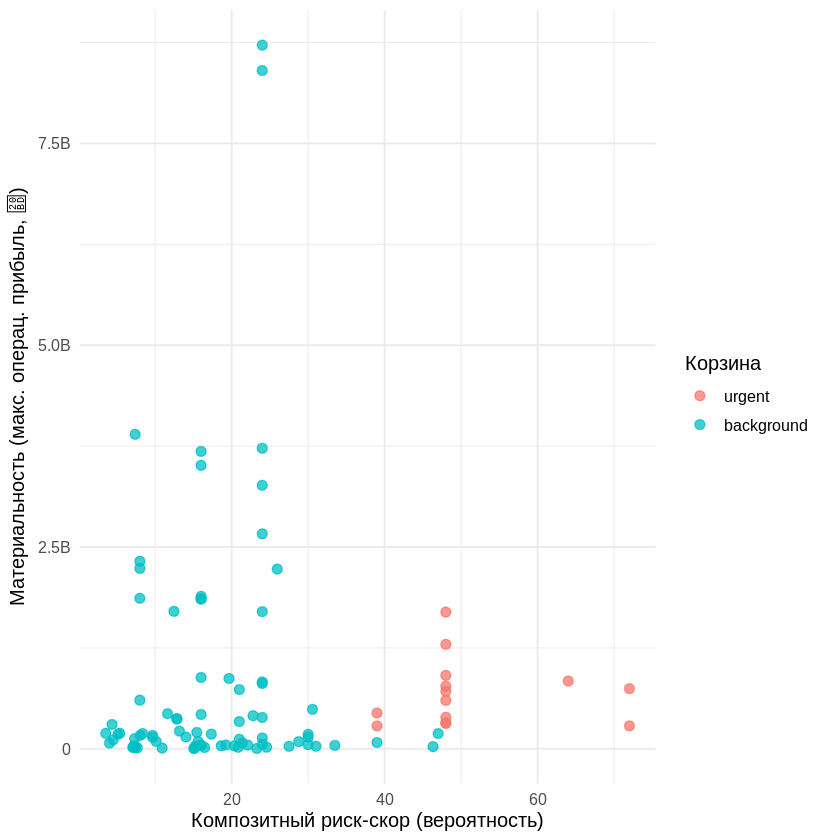

In [26]:
plot_dat <- comp %>% filter(n_flags > 0)
if (nrow(plot_dat) > 0) {
  ggplot(plot_dat, aes(composite, materiality, color = bucket)) +
    geom_point(alpha = 0.75, size = 2.4) +
    scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
    labs(x = "Композитный риск-скор (вероятность)",
         y = "Материальность (макс. операц. прибыль, ₽)", color = "Корзина") +
    theme_minimal(base_size = 12)
} else {
  cat("Нет помеченных компаний в выборке.")
}

## Частота срабатывания типологий

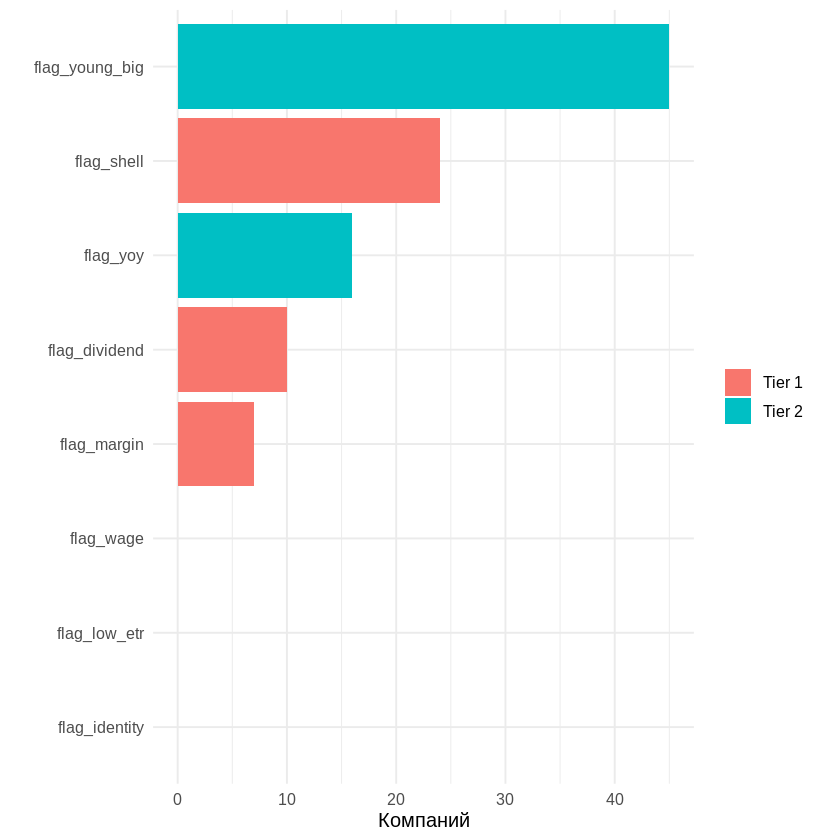

In [27]:
flag_cols <- c(TIER1_FLAGS, TIER2_FLAGS)
freq <- tibble(
  typology = flag_cols,
  n = sapply(flag_cols, function(f) sum(comp[[f]], na.rm = TRUE)),
  tier = ifelse(flag_cols %in% TIER1_FLAGS, "Tier 1", "Tier 2"))
ggplot(freq, aes(reorder(typology, n), n, fill = tier)) +
  geom_col() + coord_flip() +
  labs(x = NULL, y = "Компаний", fill = NULL) +
  theme_minimal(base_size = 12)

## Топ приоритетных находок

In [17]:
comp %>%
  filter(bucket == "urgent") %>%
  arrange(desc(composite)) %>%
  head(10) %>%
  transmute(company_id,
  company_name,
  okved_section,
  composite = round(composite, 1),
  `флагов` = n_flags,
  `материальность_₽` = comma(round(materiality))) %>%
  kable()



|company_id |company_name               |okved_section                            | composite| флагов|материальность_₽ |
|:----------|:--------------------------|:----------------------------------------|---------:|------:|:----------------|
|C0449      |ПАО «Инвест-Ко-449»        |Выращивание зерновых                     |        72|      6|745,854,682      |
|C0327      |ПАО «Союз-Пром-327»        |Грузоперевозки автомобильным транспортом |        72|      6|284,530,386      |
|C0419      |ООО «Кристалл-Холдинг-419» |Транспортная логистика                   |        64|      5|840,374,242      |
|C0008      |ООО «Омега-Маркет-008»     |Аудит и бухгалтерия                      |        48|      3|1,693,602,836    |
|C0487      |АО «Южный-Корп-487»        |Аудит и бухгалтерия                      |        48|      3|1,294,976,024    |
|C0234      |ООО «Логист-Торг-234»      |Лесозаготовка                            |        48|      3|910,736,724      |
|C0288      |ООО «Премиум-Логи

## Связанные группы (аффилированность)

### Граф аффилированности

Двудольный граф (`igraph`): **круги** — учредители (`founder_id`), **квадраты** — компании.
Цвет квадрата — корзина приоритета; толстые тёмные рёбра — группы с общим адресом (*strong*).

In [ ]:
suppressPackageStartupMessages(library(igraph))

# Функции графа — из R/05_groups.R (двудольный граф учредитель ↔ компания)
source("R/05_groups.R")

aff_graph <- build_affiliation_graph(res$cy, res$groups, comp)
if (!is.null(aff_graph)) {
  plot_affiliation_graph(aff_graph, title = "Группы аффилированности")
} else {
  cat("Граф аффилированности не построен: нет групп с >=2 компаниями.")
}

In [20]:
if (nrow(res$groups) > 0) {
  res$groups %>%
    head(8) %>%
    transmute(
    `владелец` = founder_id,
    `кол-во компаний` = n_companies,
    `сила связи` = link_strength,
    `разброс_ETR` = round(etr_spread, 3),
    `компании` = companies) %>%
      kable()
} else {
  cat("Групп из >=2 компаний с общим учредителем не обнаружено.")
}



|владелец  | кол-во компаний|сила связи   | разброс_ETR|компании                                 |
|:---------|---------------:|:------------|-----------:|:----------------------------------------|
|FND-43730 |               6|founder_only |      32.516|C0073, C0159, C0171, C0184, C0431, C0493 |
|FND-39500 |               2|founder_only |       0.732|C0443, C0458                             |
|FND-55977 |               6|strong       |       0.658|C0043, C0049, C0071, C0210, C0231, C0333 |
|FND-69325 |               6|strong       |       0.326|C0022, C0106, C0152, C0328, C0362, C0363 |